# Supply Chain Analysis
---

## Import Libraries

In [1]:
import pandas as pd
pd.set_option('display.max_columns',30)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", palette="muted", context="paper")
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

## Load the dataset

In [2]:
df = pd.read_csv(r"C:\Users\Bhawna\OneDrive\Desktop\Supply chain dataset\supply_chain_data.csv")

# display df shape
print(f"Shape: {df.shape}")
# display top 5 rows
display(df.head())

Shape: (100, 24)


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,Shipping times,Shipping carriers,Shipping costs,Supplier name,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,4,Carrier B,2.956572,Supplier 3,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,2,Carrier A,9.716575,Supplier 3,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,2,Carrier B,8.054479,Supplier 1,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,6,Carrier C,1.729569,Supplier 5,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,8,Carrier A,3.890548,Supplier 1,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


## Dataframe Check

In [3]:
# Quick dataframe check
dataframe_info = pd.DataFrame({
    "columns": df.columns,
    "dtype": [df[c].dtype for c in df.columns],
    "missing_values": [df[c].isnull().sum() for c in df.columns],
    "unique_values": [df[c].nunique() for c in df.columns]
})
# Display dataframe info now
display(dataframe_info)

,columns,dtype,missing_values,unique_values
0,Product type,object,0,3
1,SKU,object,0,100
2,Price,float64,0,100
3,Availability,int64,0,63
4,Number of products sold,int64,0,96
5,Revenue generated,float64,0,100
6,Customer demographics,object,0,4
7,Stock levels,int64,0,65
8,Lead times,int64,0,29
9,Order quantities,int64,0,61


## Basic Descriptive Statistics

In [4]:
# Basic descriptive stats
print(f"Basic Descriptive Statistics:\n{df.describe().T}")

Basic Descriptive Statistics:
                         count         mean          std          min  \
Price                    100.0    49.462461    31.168193     1.699976   
Availability             100.0    48.400000    30.743317     1.000000   
Number of products sold  100.0   460.990000   303.780074     8.000000   
Revenue generated        100.0  5776.048187  2732.841744  1061.618523   
Stock levels             100.0    47.770000    31.369372     0.000000   
Lead times               100.0    15.960000     8.785801     1.000000   
Order quantities         100.0    49.220000    26.784429     1.000000   
Shipping times           100.0     5.750000     2.724283     1.000000   
Shipping costs           100.0     5.548149     2.651376     1.013487   
Lead time                100.0    17.080000     8.846251     1.000000   
Production volumes       100.0   567.840000   263.046861   104.000000   
Manufacturing lead time  100.0    14.770000     8.912430     1.000000   
Manufacturing costs  

## Feature Engineering
1. **Demand Pressure Index** → Shows how much demand exists compared to available supply.
2. **Fill Proxy** → Tells how much of the demand actually turned into fulfilled sales.
3. **Efficiency Index**→ Measures revenue earned against shipping and operating costs.
4. **Quality‑Adjusted Efficiency** → Efficiency score adjusted for product defect risk.
5. **Composite Market Index** → A combined signal that balances demand, fulfillment, and efficiency for overall market health.

In [5]:
# Creating new metrics
df_copy = df.copy()

df_copy['Demand_pressure_index'] = df_copy['Order quantities'] / (df_copy['Availability'] + 1)
df_copy['Fill_proxy'] = df_copy['Number of products sold'] / (df_copy['Order quantities'] + 1)
df_copy['Efficiency_index'] = df_copy['Revenue generated'] / (df_copy['Shipping costs'] + df_copy['Costs'] + 1)
df_copy['Quality_adjusted_efficiency'] = df_copy['Efficiency_index'] * (1 - df_copy['Defect rates'] / 100)

df_copy['Composite_market_index'] = (
    0.40 * df_copy['Demand_pressure_index'].rank(pct=True) +
    0.25 * df_copy['Fill_proxy'].rank(pct=True) +
    0.35 * df_copy['Quality_adjusted_efficiency'].rank(pct=True)
)

indicators_cols = ['Demand_pressure_index','Fill_proxy','Efficiency_index',
                   'Quality_adjusted_efficiency','Composite_market_index']
df_copy[indicators_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Demand_pressure_index,100.0,2.083425,3.449470,0.015385,0.575435,0.967742,2.032143,26.000000
Fill_proxy,100.0,19.652260,48.288622,0.089888,4.250783,8.439429,17.606481,452.000000
Efficiency_index,100.0,15.389875,15.041170,1.925100,5.904197,10.909112,16.205738,86.874164
Quality_adjusted_efficiency,100.0,15.076400,14.824033,1.913049,5.773185,10.696248,15.677403,86.246755
Composite_market_index,100.0,0.505000,0.150891,0.152000,0.391750,0.495500,0.618000,0.855500


## Exploratory Data Analysis

,Location,Demand_pressure_index
1,Chennai,2.504025
3,Kolkata,2.448499
4,Mumbai,2.157532
2,Delhi,1.641389
0,Bangalore,1.386832


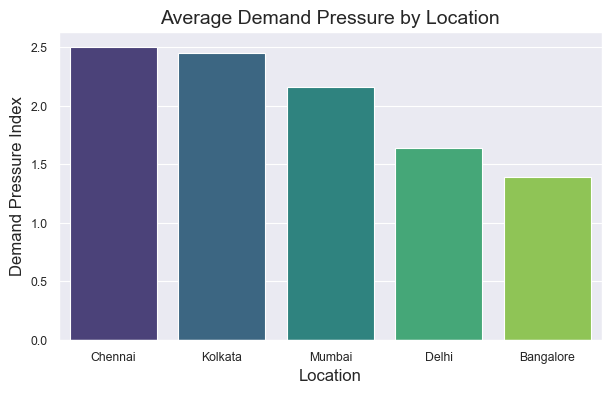

In [6]:
# Demand pressure by location
loc_pressure = df_copy.groupby('Location', as_index=False)['Demand_pressure_index']\
    .mean().sort_values('Demand_pressure_index', ascending=False)
display(loc_pressure)

plt.figure(figsize=(7,4))
sns.barplot(x=loc_pressure['Location'], y=loc_pressure['Demand_pressure_index'],
            palette='viridis')
plt.title("Average Demand Pressure by Location", fontsize=14)
plt.xlabel("Location",fontsize=12)
plt.ylabel("Demand Pressure Index",fontsize=12)
plt.show()


,Product type,Demand_pressure_index
1,haircare,2.434970
2,skincare,1.921306
0,cosmetics,1.873126


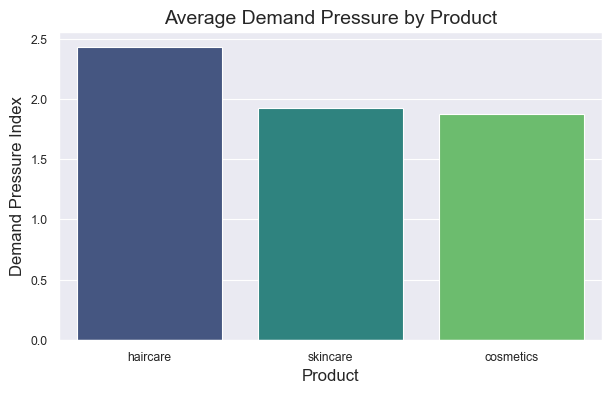

In [7]:
# Demand pressure by product type
prod_pressure = df_copy.groupby('Product type', as_index=False)['Demand_pressure_index']\
    .mean().sort_values('Demand_pressure_index',ascending=False)
display(prod_pressure)

plt.figure(figsize=(7,4))
sns.barplot(x=prod_pressure['Product type'], y=prod_pressure['Demand_pressure_index'],
            palette='viridis')
plt.title("Average Demand Pressure by Product", fontsize=14)
plt.xlabel("Product",fontsize=12)
plt.ylabel("Demand Pressure Index",fontsize=12)
plt.show()


,Transportation modes,Quality_adjusted_efficiency
3,Sea,21.834011
0,Air,15.593995
1,Rail,13.282494
2,Road,12.383036


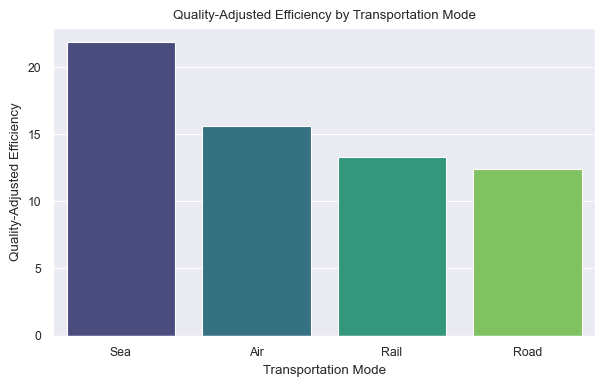

In [8]:
# Quality adjusted efficiency by transportation mode
mode_eff = (
    df_copy.groupby('Transportation modes', as_index=False)['Quality_adjusted_efficiency']
    .mean().sort_values('Quality_adjusted_efficiency',ascending=False)
)

display(mode_eff)

plt.figure(figsize=(7,4))
sns.barplot(x=mode_eff["Transportation modes"], y=mode_eff["Quality_adjusted_efficiency"],
            palette='viridis')
plt.title("Quality-Adjusted Efficiency by Transportation Mode")
plt.xlabel("Transportation Mode")
plt.ylabel("Quality-Adjusted Efficiency")
plt.show()

,Location,Composite_market_index
4,Mumbai,0.542705
3,Kolkata,0.539780
2,Delhi,0.512600
1,Chennai,0.472300
0,Bangalore,0.440611


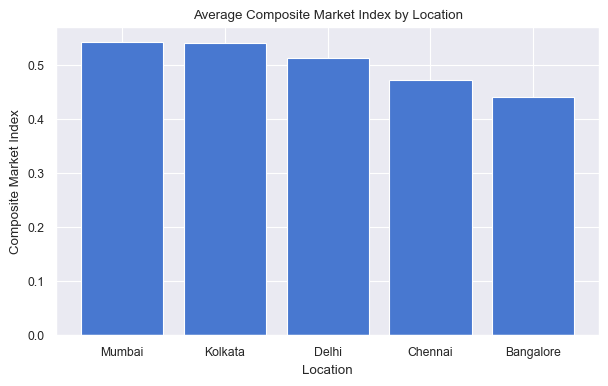

In [9]:
# Top locations by composite index
loc_composite = (
    df_copy.groupby('Location', as_index=False)['Composite_market_index']
    .mean().sort_values('Composite_market_index', ascending=False)
)

display(loc_composite)

plt.figure(figsize=(7,4))
plt.bar(loc_composite["Location"], loc_composite["Composite_market_index"])
plt.title("Average Composite Market Index by Location")
plt.xlabel("Location")
plt.ylabel("Composite Market Index")
plt.show()

In [10]:
# Top SKU(inventory item) by composite index score
top_skus = df_copy.sort_values('Composite_market_index', ascending=False)[
    ["SKU", "Location", "Product type", "Demand_pressure_index", "Fill_proxy",
     "Quality_adjusted_efficiency", "Composite_market_index"]
].head(10)

display(top_skus)

,SKU,Location,Product type,Demand_pressure_index,Fill_proxy,Quality_adjusted_efficiency,Composite_market_index
52,SKU52,Mumbai,skincare,5.500000,68.333333,15.077626,0.8555
99,SKU99,Chennai,haircare,3.277778,10.450000,42.962822,0.8095
67,SKU67,Mumbai,skincare,4.176471,7.125000,52.732790,0.8015
28,SKU28,Mumbai,cosmetics,1.846154,15.760000,45.166297,0.8015
37,SKU37,Kolkata,skincare,3.500000,43.772727,12.735282,0.7980
71,SKU71,Bangalore,cosmetics,1.733333,23.592593,19.283533,0.7700
0,SKU0,Mumbai,haircare,1.714286,8.268041,45.080831,0.7275
60,SKU60,Mumbai,skincare,4.235294,5.205479,19.770807,0.7255
88,SKU88,Mumbai,cosmetics,1.440678,8.569767,86.246755,0.7215
18,SKU18,Kolkata,haircare,1.916667,13.191489,15.289515,0.7210


In [12]:
# Bottleneck detection
# high pressure + low fill + high defect rate
bottlenecks = df_copy[
    (df_copy['Demand_pressure_index'] > df_copy['Demand_pressure_index'].median()) &
    (df_copy['Fill_proxy'] < df_copy['Fill_proxy'].median()) &
    (df_copy['Defect rates'] > df_copy['Defect rates'].median())
][[
    "SKU", "Location", "Product type", "Demand_pressure_index",
    "Fill_proxy", "Defect rates", "Shipping costs", "Costs"
]].sort_values(['Demand_pressure_index','Defect rates'], ascending=[False, False])

display(bottlenecks.head(10))

,SKU,Location,Product type,Demand_pressure_index,Fill_proxy,Defect rates,Shipping costs,Costs
45,SKU45,Chennai,haircare,26.000000,0.452830,3.219605,5.215155,495.305697
29,SKU29,Kolkata,cosmetics,16.750000,3.720588,3.878099,8.100973,764.935376
82,SKU82,Mumbai,skincare,5.142857,4.602740,4.137877,4.708182,589.978556
60,SKU60,Mumbai,skincare,4.235294,5.205479,2.853091,4.381368,430.169097
77,SKU77,Kolkata,haircare,3.800000,6.189655,3.055142,6.780947,852.568099
20,SKU20,Chennai,skincare,2.956522,4.637681,4.231417,8.878335,493.871215
2,SKU2,Mumbai,haircare,2.514286,0.089888,4.580593,8.054479,141.920282
87,SKU87,Chennai,haircare,2.200000,1.410714,3.693738,6.575804,879.359218
12,SKU12,Kolkata,haircare,2.023810,3.906977,2.161254,1.325274,402.968789
73,SKU73,Chennai,cosmetics,1.571429,5.597015,4.620546,1.512937,866.472800


Suggested Actions:
- High pressure + low fill  -> increase capacity or revise allocation
- High defect + high cost   -> prioritize quality improvement
- High efficiency + high pressure -> candidate for expansion

In [14]:
# Correlation view
corr_cols = [ "Order quantities", "Availability", "Stock levels", "Shipping costs", "Costs",
    "Defect rates", "Number of products sold", "Revenue generated",
    "Demand_pressure_index", "Fill_proxy", "Quality_adjusted_efficiency",
    "Composite_market_index"]

corr_target =df_copy[corr_cols].corr(numeric_only=True)['Composite_market_index']\
    .sort_values(ascending=False).reset_index()
corr_target.columns = ['Features', 'Correlation with Composite']

display(corr_target)

,Features,Correlation with Composite
0,Composite_market_index,1.000000
1,Quality_adjusted_efficiency,0.569543
2,Revenue generated,0.508515
3,Number of products sold,0.369486
4,Demand_pressure_index,0.308032
5,Order quantities,0.072918
6,Fill_proxy,0.042018
7,Shipping costs,0.007550
8,Stock levels,-0.083890
9,Defect rates,-0.171058


In [15]:
## Thank YOu